## Exercice 0. Getting Started: Ring Attractors in 1D

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d
from scipy.ndimage import convolve
from scipy.stats import linregress

Question 1

In [2]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh) : 
    weight = (A_exc*math.exp(-x**2/sigma_exc**2)) - (A_inh*math.exp(-x**2/sigma_inh**2))

    return weight


Question 2

In [3]:
M = 100
A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0 

#positions of neurons centered around 0 

x_values = np.arange(-M/2, M/2)

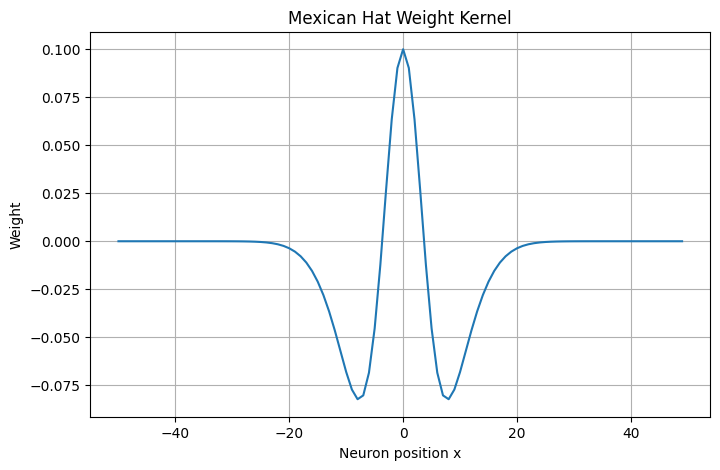

In [4]:
# Weights calculation 

weights = [mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh) for x in x_values]

#Plot

plt.figure(figsize=(8,5))
plt.plot(x_values, weights)

plt.title("Mexican Hat Weight Kernel")
plt.xlabel("Neuron position x")
plt.ylabel("Weight")
plt.grid(True)
plt.show()

Question 3

The Mexican hat kernel represents a common feature of cortical connectivity which is local excitation combined with long-range inhibition. Nearby neurons tend to excite each other, while neurons farther away produce inhibitory effects. This organization is frequently observed in cortical neural circuits. 

The kernel is defined as:

$$
w(x)=A_{exc}e^{-x^2/\sigma_{exc}^2}-A_{inh}e^{-x^2/\sigma_{inh}^2}
$$

where:
- $A_{exc}$ and $\sigma_{exc}$ control the strength and spatial range of excitation,
- $A_{inh}$ and $\sigma_{inh}$ control the strength and spatial range of inhibition.

Since: $$\sigma_{inh} > \sigma_{exc}$$ inhibition spreads over a wider region than excitation. 

Biologicaly, this connectivity pattern alows: 
- competition between neurons
- stimulus selection
- contrast enhancement 
- pattern formation
... 

In the plot, the positive central region corresponds to strong local excitation, while the negative surrounding region corresponds to broader inhibition. 

Question 4

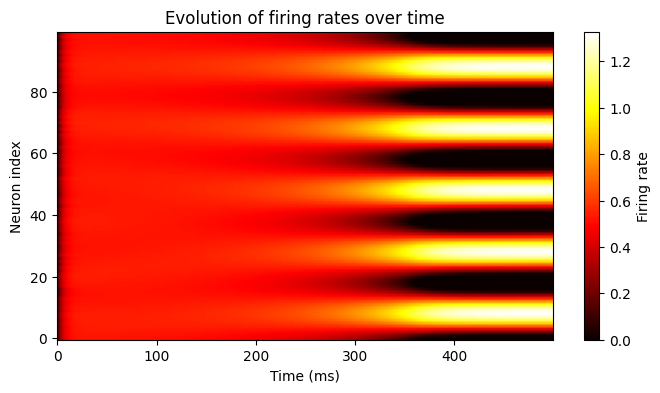

In [5]:
# Simulation parameters

dt = 1.0
T = 500
tau = 10.0
B = 1.0

# Initial potentials 

np.random.seed(0) # change seed for initialization and check behavior

s = np.random.uniform(0, 0.1, M)

# Store firing rates of every neuron over time
r_history = np.zeros((T,M)) 

# Simulation loop 
for t in range(T): 
    #ReLU firing rates over time 
    r = np.maximum(0,s)
    # Store activity
    r_history[t] = r
    # Recurrent input with periodic boundary conditions
    I_rec = convolve1d(r, weights, mode='wrap')
    # Differential equation 
    dsdt = (-s + I_rec + B) / tau
    # Forwars Euler update 
    s = s + dt * dsdt

# Heatmap of firing rates 
plt.figure(figsize=(8,4))

plt.imshow(
    r_history.T,
    aspect='auto',
    origin='lower',
    cmap='hot'
)

plt.colorbar(label='Firing rate')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Evolution of firing rates over time')

plt.show()

Question 5

The network activity evolves from a random initial condition toward a structured spatial pattern.  
At the beginning of the simulation, the firing rates are weak and irregular because the potentials
\(s(x,0)\) are randomly initialized.

As time progresses, the recurrent connectivity amplifies local activity through short-range excitation,
while long-range inhibition suppresses neighboring regions. This interaction produces localized regions
of high activity that propagate around the ring because of the periodic boundary conditions.

The heatmap shows:
- smooth spatial organization of activity,
- amplification of specific neuronal populations,
- suppression of surrounding neurons due to inhibition.

The dynamics become increasingly structured over time, indicating that the recurrent connectivity
dominates over the initial random fluctuations.

Different seeds produce slightly different early dynamics because the initial perturbations are different. However the global qualitative behavior network remains simila in all cases. 

The network still develops organized activity patterns, excitation and inhibition still create structured bumps of activity, the ring topology remains visible. 

Therefore, the precise trajectory depends somewhat on the initialization, but the overall behavior is
mainly determined by the recurrent Mexican-hat connectivity and not by the exact initial condition.

## Exercice 1. 1D Velocity Integration

Question 1

In [6]:

# Parameters for the 2-population model

T = 1000
B0 = 1.5
alpha = 0.5
l = 1.0

# Shifted connectivity kernels 

W_R = np.roll(weights, int(l)) 
W_L = np.roll(weights, -int(l))

# Initial potentials 

np.random.seed(0)

s_R = np.random.uniform(0, 0.1, M)
s_L = np.random.uniform(0, 0.1, M)

# Store total activity 

r_total_history = np.zeros((T, M))

In [7]:
# Simulation loop

for t in range(T):

    # Velocity protocol
    if t < 300:
        v = 0.0

    elif t < 700:
        v = 1.0

    else:
        v = 0.0

    # External inputs
    B_R = B0 * (1 + alpha * v)
    B_L = B0 * (1 - alpha * v)

    # ReLU firing rates
    r_R = np.maximum(0, s_R)
    r_L = np.maximum(0, s_L)

    # Total activity
    r_total_history[t] = r_R + r_L

    # Recurrent inputs
    I_R = convolve1d(r_R, W_R, mode='wrap')
    I_L = convolve1d(r_L, W_L, mode='wrap')

    # Total recurrent input
    I_rec = I_R + I_L

    # Dynamics
    dsdt_R = (-s_R + I_rec + B_R) / tau
    dsdt_L = (-s_L + I_rec + B_L) / tau

    # Euler update
    s_R = s_R + dt * dsdt_R
    s_L = s_L + dt * dsdt_L


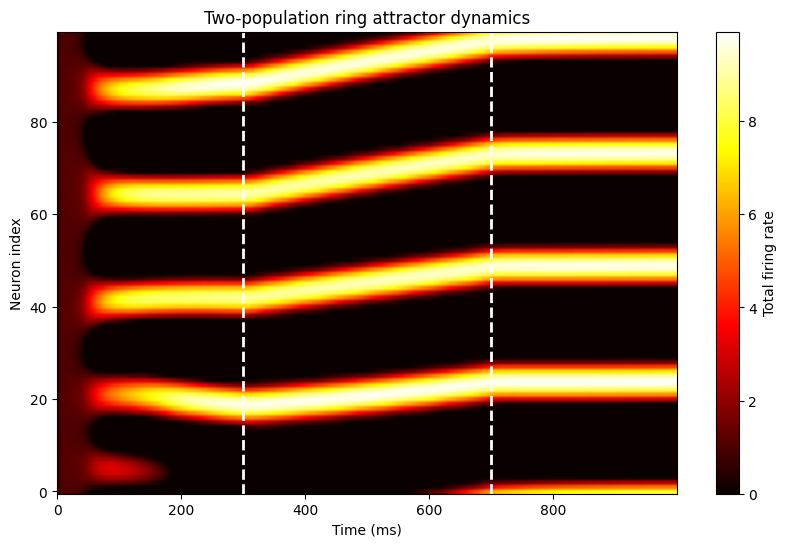

In [8]:
# Plot total firing rates 

plt.figure(figsize=(10,6))

plt.imshow(
    r_total_history.T,
    aspect='auto',
    origin='lower',
    cmap='hot'
)

plt.axvline(x=300, color='white', linestyle='--', linewidth=2)
plt.axvline(x=700, color='white', linestyle='--', linewidth=2)

plt.colorbar(label='Total firing rate')

plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')

plt.title('Two-population ring attractor dynamics')

plt.show()

Question 2

The network contains two interacting populations, a right-shifting population \(R\), and a left-shifting population \(L\).

The connectivity of each population is slightly shifted. \(R\) projects preferentially to neurons located slightly to the right and \(L\) projects preferentially to neurons located slightly to the left.

The external inputs are modulated by the velocity signal \(v(t)\):

$$
B_R = B_0(1+\alpha v)
$$

$$
B_L = B_0(1-\alpha v)
$$

When \(v=0\), both populations receive the same input:

$$
B_R = B_L
$$

As a result, the rightward and leftward influences balance each other, and the activity bump remains stable at a fixed position on the ring.

When \(v>0\), the input to the \(R\) population becomes larger than the input to the \(L\) population:

$$
B_R > B_L
$$

The right-shifting population becomes more active and contributes more strongly to the recurrent input. Since its connectivity is shifted toward the right, it preferentially excites neurons located slightly ahead of the current bump position.

At the same time, the left-shifting population becomes weaker and contributes less to leftward stabilization.

This imbalance causes the bump of activity to progressively move to the right along the ring.

Similarly, if \(v<0\), the \(L\) population would dominate and the bump would move to the left.

Thus, the velocity signal controls the direction and speed of bump displacement through asymmetric interactions between the two populations.

Question 3

In [9]:
T = 3000 # 10 velocity segments x 300 ms

# sample 10 velocities in [-2, -0.5] U [0.5, 2]
negative_velocities = np.random.uniform(-2, -0.5, 5)
positive_velocities = np.random.uniform(0.5, 2, 5)

velocities = np.concatenate([negative_velocities, positive_velocities])

# Shuffle velocities 
np.random.shuffle(velocities)

# velocity signal over time 
v_signal = np.zeros(T)

for i, v in enumerate(velocities) : 
    start = i * 300
    end = (i+1) * 300 

    v_signal[start:end] = v

# initial conditions 

np.random.seed(0)

s_R = np.random.uniform(0, 0.1, M)
s_L = np.random.uniform(0, 0.1, M)

# Store activity 
r_total_history = np.zeros((T,M))

In [10]:
# Simulation loop 

for t in range(T): 

    # Current velocity
    v = v_signal[t]

    # External inputs
    B_R = B0 * (1 + alpha * v)
    B_L = B0 * (1 - alpha * v)

    # ReLU activations
    r_R = np.maximum(0, s_R)
    r_L = np.maximum(0, s_L)

    # Store total activity
    r_total_history[t] = r_R + r_L

    # Recurrent inputs
    I_R = convolve1d(r_R, W_R, mode='wrap')
    I_L = convolve1d(r_L, W_L, mode='wrap')

    I_rec = I_R + I_L

    # Dynamics
    dsdt_R = (-s_R + I_rec + B_R) / tau
    dsdt_L = (-s_L + I_rec + B_L) / tau

    # Euler update
    s_R = s_R + dt * dsdt_R
    s_L = s_L + dt * dsdt_L


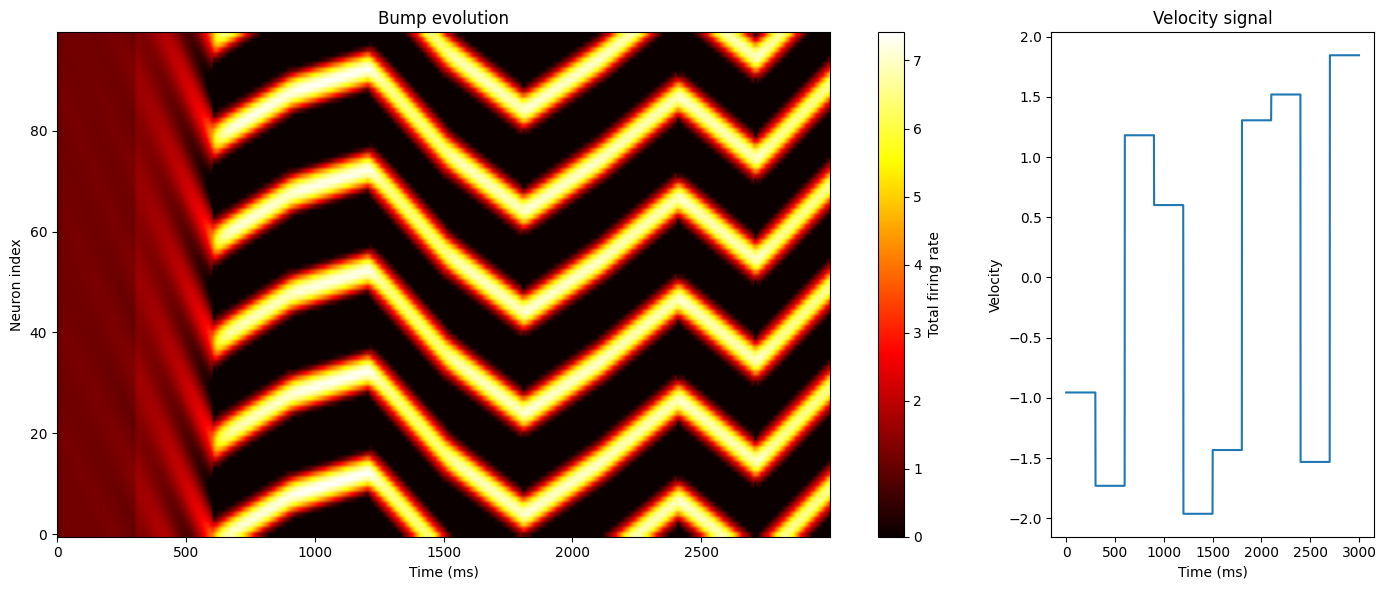

In [11]:
# plot 

fig, axes = plt.subplots(
    1, 2,
    figsize=(14,6),
    gridspec_kw={'width_ratios': [3,1]}
)

# Heatmap
im = axes[0].imshow(
    r_total_history.T,
    aspect='auto',
    origin='lower',
    cmap='hot'
)

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Neuron index')
axes[0].set_title('Bump evolution')

# Velocity plot
axes[1].plot(np.arange(T), v_signal)


axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Velocity')
axes[1].set_title('Velocity signal')

plt.colorbar(im, ax=axes[0], label='Total firing rate')

plt.tight_layout()
plt.show()

The activity bumb follows the velociry signal over time: when the velocity is positive, the bump moves toward increasing neuron indices. When the velocity becomes negaive, the direction of motion reverses and the bump moves toward decreasing neuron indices. 

The slope of the bump depends on the magnitude of the velocity. Larger absolute velocities produce faster motion while smaller velocities produce slower displacement. 

Overall, the network behaves as a velocity integrator: the velocity input controls the directions and speed of the bump, and the bump position continuously encodes the integrated motion over time. 

Question 4

To estimate the velocity of the activity bump, we compute the center of mass of the total firing activity at each timestep.

The bump position is defined as:

$$
x_{bump}(t)
=
\frac{\sum_x x \, r_{total}(x,t)}
{\sum_x r_{total}(x,t)}
$$

where:

$$
r_{total}(x,t)=r_R(x,t)+r_L(x,t)
$$

The bump velocity is then estimated using finite differences:

$$
v_{bump}(t)
=
\frac{x_{bump}(t+1)-x_{bump}(t)}{\Delta t}
$$

For each 300 ms segment of constant input velocity, we compute the average bump velocity and compare
it to the true input velocity.

In [12]:
# Compute bump position over time 

positions = np.arange(M)

bump_position = np.zeros(T)

for t in range (T):
    activity = r_total_history[t]

    bump_position[t] = (np.sum(positions *activity)/np.sum(activity))

# compute bump velocity 

bump_velocity = np.diff(bump_position) / dt

# average bump velocity for each segment 

measured_velocities = []

for i in range(len(velocities)):

    start = i * 300
    end = (i + 1) * 300

    # Mean bump velocity during the segment
    mean_velocity = np.mean(
        bump_velocity[start:end-1]
    )

    measured_velocities.append(mean_velocity)

measured_velocities = np.array(measured_velocities)


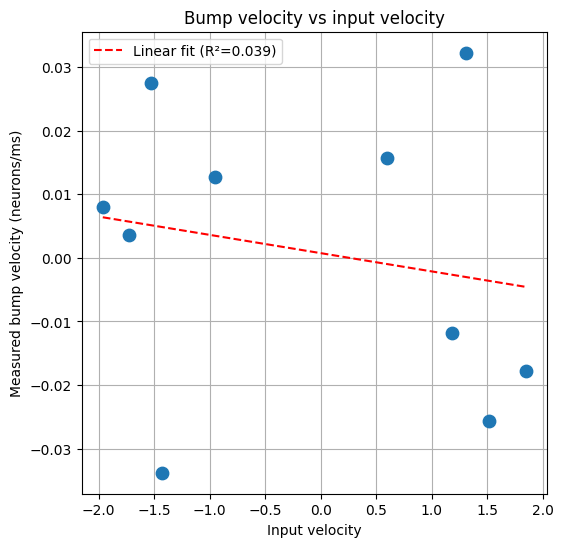

In [13]:
# Plot measured vs input velocity 

plt.figure(figsize=(6,6))

plt.scatter(
    velocities,
    measured_velocities,
    s=80,
    zorder=5
)

# Linear regression to quantify the relationship
slope_fit, intercept_fit, r_val, _, _ = linregress(velocities, measured_velocities)
v_range = np.linspace(velocities.min(), velocities.max(), 100)
plt.plot(v_range, slope_fit * v_range + intercept_fit, 'r--',
         label=f'Linear fit (R²={r_val**2:.3f})')

plt.xlabel('Input velocity')
plt.ylabel('Measured bump velocity (neurons/ms)')
plt.title('Bump velocity vs input velocity')
plt.grid(True)
plt.legend()
plt.show()


## Exercice 2. Extending to 2D Grid Cells

Question 1

In [14]:
def mexican_hat_2d(X, Y, A_exc, sigma_exc, A_inh, sigma_inh):
    r_squared = X**2 + Y**2
   
    return A_exc * np.exp(-r_squared / sigma_exc**2) - A_inh * np.exp(-r_squared / sigma_inh**2)


In [15]:
# Parameters

M = 40
A_exc = 1.0
A_inh = 1.0
sigma_exc = 4.8
sigma_inh = 5.0

# 2D grid of neuron positions centered around 0 

x_vals = np.arange(-M/2, M/2)
y_vals = np.arange(-M/2, M/2)
X, Y = np.meshgrid(x_vals, y_vals)

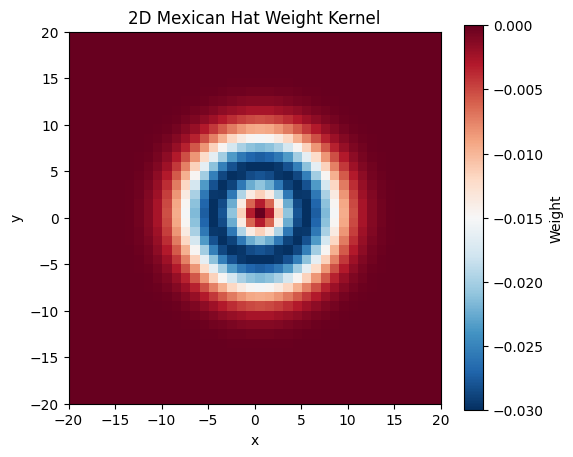

In [16]:
# Compute the 2D weight kernel

W_2d = mexican_hat_2d(X, Y, A_exc, sigma_exc, A_inh, sigma_inh)

# Plot

plt.figure(figsize=(6, 5))

plt.imshow(W_2d, 
           origin='lower', 
           cmap='RdBu_r',
           extent=[-M/2, M/2, -M/2, M/2])

plt.colorbar(label='Weight')

plt.title('2D Mexican Hat Weight Kernel')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Question 2

In [17]:
# Parameters

tau = 10.0
dt = 1.0
T = 400
B0 = 1.0
alpha = 0.1
l = 1.0
vx, vy = 0.0, 0.0

In [18]:
# Shifted 2D kernels for each population

W_N = np.roll(W_2d, int(l), axis=0)   # shift up (North)
W_S = np.roll(W_2d, -int(l), axis=0)  # shift down (South)
W_E = np.roll(W_2d, int(l), axis=1)   # shift right (East)
W_W = np.roll(W_2d, -int(l), axis=1)  # shift left (West)

In [19]:
# Random initialization of potentials for each population

np.random.seed(0)

s_N = np.random.uniform(0, 0.1, (M, M))
s_S = np.random.uniform(0, 0.1, (M, M))
s_E = np.random.uniform(0, 0.1, (M, M))
s_W = np.random.uniform(0, 0.1, (M, M))

In [20]:
# Simulation loop

for t in range(T):

    # ReLU firing rates
    r_N = np.maximum(0, s_N)
    r_S = np.maximum(0, s_S)
    r_E = np.maximum(0, s_E)
    r_W = np.maximum(0, s_W)

    # External inputs modulated by velocity
    B_N = B0 * (1 + alpha * vy)
    B_S = B0 * (1 - alpha * vy)
    B_E = B0 * (1 + alpha * vx)
    B_W = B0 * (1 - alpha * vx)

    # Recurrent inputs with periodic boundary conditions (mode='wrap')
    I_N = convolve(r_N, W_N, mode='wrap')
    I_S = convolve(r_S, W_S, mode='wrap')
    I_E = convolve(r_E, W_E, mode='wrap')
    I_W = convolve(r_W, W_W, mode='wrap')

    # Total recurrent input (sum of all 4 populations)
    I_rec = I_N + I_S + I_E + I_W

    # Euler update for each population
    s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
    s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
    s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
    s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

# Total firing rate at final timestep
r_total_2d = (np.maximum(0, s_N) + np.maximum(0, s_S) +
              np.maximum(0, s_E) + np.maximum(0, s_W))

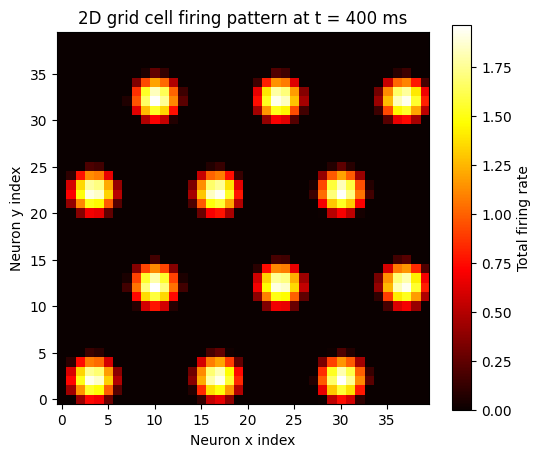

In [21]:
# Plot heatmap 

plt.figure(figsize=(6, 5))

plt.imshow(r_total_2d, 
           origin='lower', 
           cmap='hot')
plt.colorbar(label='Total firing rate')

plt.title('2D grid cell firing pattern at t = 400 ms')
plt.xlabel('Neuron x index')
plt.ylabel('Neuron y index')

plt.show()

A clear grid pattern is visible in the heatmap. The total firing rate shows multiple localized bumps of activity arranged in a regular, periodic structure across the 2D neural sheet. The bumps are evenly spaced and form a hexagonal lattice, which is the hallmark signature of grid cells.

This pattern emerges from the balance between short-range excitation and long-range inhibition encoded in the Mexican hat kernel, combined with the four shifted populations (N, S, E, W) and periodic boundary conditions. The recurrent connectivity causes the network to self-organize into this stable multi-bump configuration, where each bump suppresses its neighbors through lateral inhibition while sustaining itself through local excitation.

Question 3

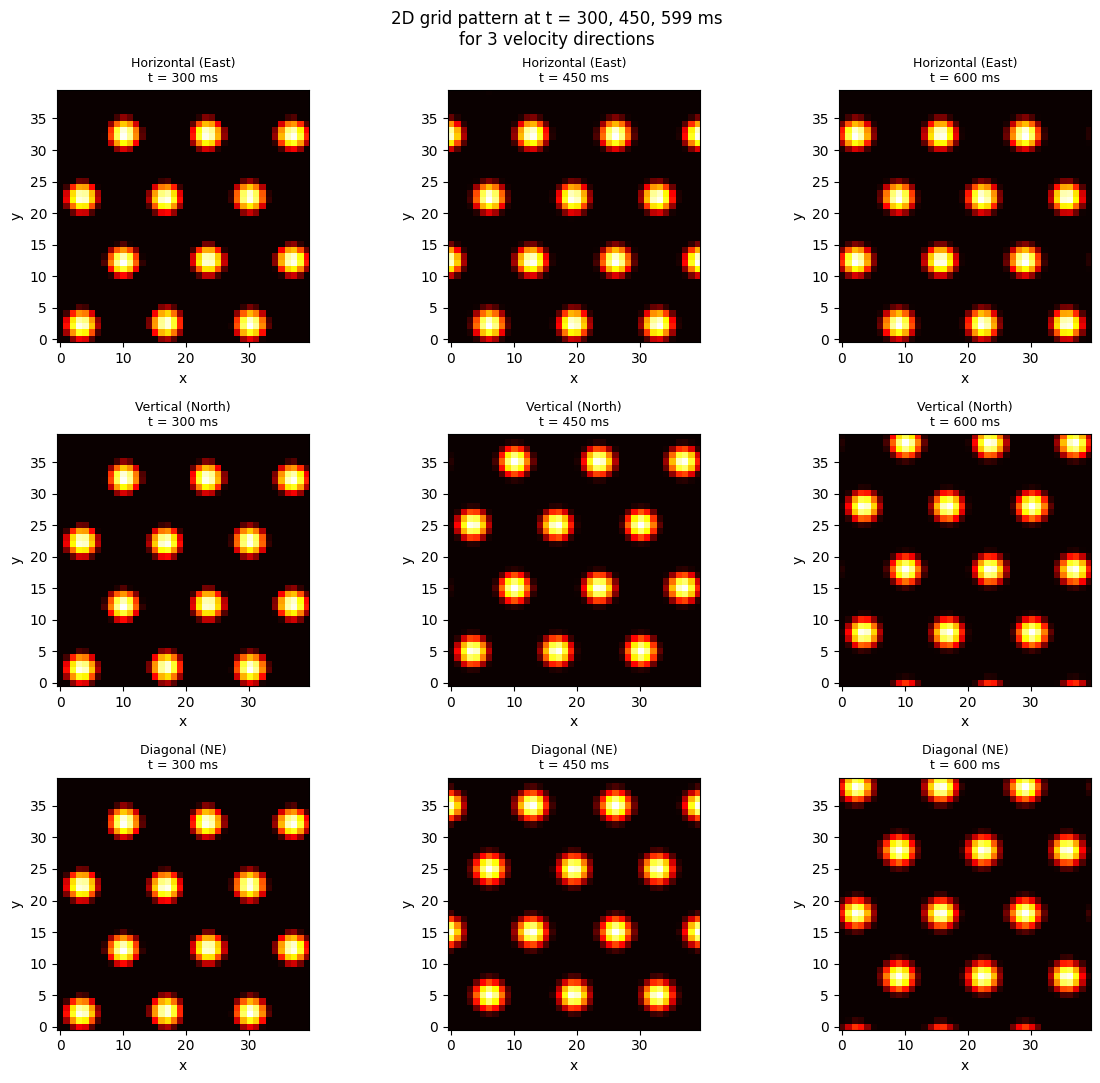

In [22]:
velocity_cases = [
    ('Horizontal (East)',  1.0,  0.0),
    ('Vertical (North)',   0.0,  1.0),
    ('Diagonal (NE)',      1.0,  1.0),
]

fig, axes = plt.subplots(3, 3, figsize=(12, 11))

for row, (label, vx, vy) in enumerate(velocity_cases):

    # Random initialization
    np.random.seed(0)
    s_N = np.random.uniform(0, 0.1, (M, M))
    s_S = np.random.uniform(0, 0.1, (M, M))
    s_E = np.random.uniform(0, 0.1, (M, M))
    s_W = np.random.uniform(0, 0.1, (M, M))

    snapshots = {}

    # Simulation loop: 300 ms stabilization + 300 ms with velocity
    for t in range(600):

        # Velocity protocol
        if t < 300:
            vx_t, vy_t = 0.0, 0.0
        else:
            vx_t, vy_t = vx, vy

        # External inputs modulated by velocity
        B_N = B0 * (1 + alpha * vy_t)
        B_S = B0 * (1 - alpha * vy_t)
        B_E = B0 * (1 + alpha * vx_t)
        B_W = B0 * (1 - alpha * vx_t)

        # ReLU firing rates
        r_N = np.maximum(0, s_N)
        r_S = np.maximum(0, s_S)
        r_E = np.maximum(0, s_E)
        r_W = np.maximum(0, s_W)

        # Snapshot at t=300, 450, 599
        if t in [299, 449, 599]:
            snapshots[t] = r_N + r_S + r_E + r_W

        # Recurrent inputs with periodic boundary conditions
        I_rec = (convolve(r_N, W_N, mode='wrap') +
                 convolve(r_S, W_S, mode='wrap') +
                 convolve(r_E, W_E, mode='wrap') +
                 convolve(r_W, W_W, mode='wrap'))

        # Euler update
        s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
        s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
        s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
        s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

    # Plot the 3 snapshots
    for col, (t_snap, t_label) in enumerate(zip([299, 449, 599], [300, 450, 600])):
        ax = axes[row, col]
        ax.imshow(snapshots[t_snap], origin='lower', cmap='hot', vmin=0)
        ax.set_title(f'{label}\nt = {t_label} ms', fontsize=9)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

plt.suptitle('2D grid pattern at t = 300, 450, 599 ms\nfor 3 velocity directions', fontsize=12)
plt.tight_layout()
plt.show()